# Лекция 2. Ценность действия и уравнение Беллмана

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/02-environments/lecture/lecture.ipynb)

**Главный вопрос сегодня: как выбрать действие сейчас, если награда придёт потом?**

На прошлой лекции мы искали хорошую стратегию перебором: играли сотни эпизодов, отбирали удачные, повторяли их действия. Сегодня научимся **считать**, насколько хорош каждый шаг, — и стратегия получится из этих чисел сама. Числа называются ценностью, а считает их уравнение Беллмана: одно уравнение, на котором стоит весь остальной курс.

Путь лекции — три шага:

1. **Оценки.** Если бы кто-то дал нам таблицу «насколько хорошо сделать это действие в этой клетке», стратегия получалась бы даром.
2. **Уравнение.** Эти оценки связаны друг с другом уравнением Беллмана, и из него их можно вычислить.
3. **Без модели.** Если устройство среды неизвестно, то же уравнение работает по одному сыгранному шагу за раз — это Q-learning.

| | Раздел | Минут |
|---|---|---|
| 1 | Где мы остановились | 6 |
| 2 | Мир, на котором всё посчитаем | 10 |
| 3 | Если бы у нас были оценки: $Q$ и $V$ | 14 |
| 4 | Уравнение Беллмана | 18 |
| 5 | Это называется MDP | 10 |
| 6 | Насколько хороша заданная стратегия | 10 |
| 7 | Когда модель неизвестна: Q-learning | 17 |
| 8 | Итоги | 5 |

Изложение следует главе [«Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) Учебника по машинному обучению ШАД: оттуда взяты и ход рассуждений, и примеры (клетчатый мир, Колобок с лотереей). Служебный код вынесен в файлы `gridworld.py` и `gridworld_plots.py` рядом с ноутбуком — читать их не нужно. Пометка **⏱** — резерв, если останется время.

In [1]:
# В Google Colab: скачиваем два служебных файла лекции. Локально (файлы лежат рядом) ячейка ничего не делает.
import pathlib, urllib.request
for name in ["gridworld.py", "gridworld_plots.py"]:
    if not pathlib.Path(name).exists():
        urllib.request.urlretrieve("https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/02-environments/lecture/" + name, name)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld import *          # GridWorld, mdp_matrices, run_episode, average_return, solve_q_star, greedy_policy, GAMMA
from gridworld_plots import *    # draw_grid, plot_values, plot_q, draw_policy, draw_transitions, draw_paths, draw_backup

env = GridWorld()                # мир из раздела 2
P, R = mdp_matrices(env)         # модель среды: P[s, a, s'] и средняя награда R[s, a]
Q_star = solve_q_star(P, R)      # «ответ» для раздела 3; как он считается — раздел 4
V_star = Q_star.max(axis=1)
print(f"клеток: {env.n_states}, действий: {env.n_actions}, дисконт γ = {GAMMA}")

клеток: 12, действий: 4, дисконт γ = 0.95


## 1. Где мы остановились

В лекции 1 мы написали первый алгоритм RL — метод Cross-Entropy: сыграть 200 эпизодов, отобрать лучшие 30%, повторять действия из них, и так 25 раз. Работает, но посмотрите, **чем** он пользуется.

![мост](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/from_episodes_to_steps.png)

Cross-Entropy видит только **итог эпизода**: одно число на сотню шагов. Агент мог сделать 99 правильных шагов и один раз оступиться — эпизод уйдёт в мусор целиком, вместе с 99 правильными шагами. А в большой среде удачные эпизоды вообще почти не встречаются, и отбирать нечего.

Хочется другого: оценки **на каждый шаг** — «насколько хорошо сделать вот это действие вот в этой клетке». Тогда учиться можно с каждого шага, а не с каждого эпизода. Вся сегодняшняя лекция — про то, откуда такие оценки берутся.

## 2. Мир, на котором всё посчитаем

Frozen Lake из прошлой лекции мы отложим: там агента сносит в две стороны из трёх, и рассуждать о числах тяжело. Возьмём мир попроще — тот самый клетчатый мир, который мелькал в лекции 1 (он же стандартный пример из учебника ШАД).

![правила](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/gridworld_rules.png)

Правила целиком:

* агент стоит в одной из **12 клеток** (клетка 5 — стена, туда нельзя);
* на каждом шаге выбирает одно из **четырёх действий** — попытку шагнуть влево, вниз, вправо или вверх;
* **ветер**: с вероятностью 0.8 агент идёт куда просил, с вероятностью 0.1 его сносит в каждую из двух боковых сторон; шаг в стену или за край оставляет его на месте;
* **награда**: −0.04 за каждый шаг (время дорого, гулять вечно невыгодно), +1 за вход в зелёную клетку, −1 за вход в красную;
* попав в зелёную или красную клетку, агент останавливается — **эпизод закончен**.

Ветер — единственное, что делает задачу интересной: намерение и результат не совпадают. Посмотрим на него.

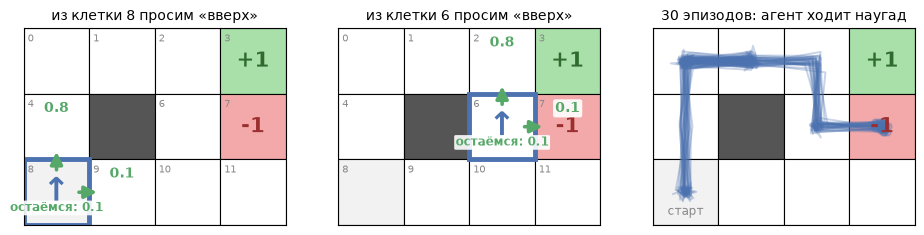

средний return случайной стратегии: -0.67


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
draw_transitions(env, s=8, a=3, ax=axes[0])     # из старта просим «вверх»
draw_transitions(env, s=6, a=3, ax=axes[1])     # а здесь ветер может занести в яму
draw_paths([run_episode(env, uniform_policy(env), np.random.default_rng(0)) for _ in range(30)], env,
           ax=axes[2], title="30 эпизодов: агент ходит наугад")
plt.show()

rng = np.random.default_rng(0)
print(f"средний return случайной стратегии: {average_return(env, uniform_policy(env), rng):+.2f}")

Слева: попросили «вверх» из старта — с вероятностью 0.8 поднялись, по 0.1 остались на месте (слева стена мира) или уехали вправо. В середине: из клетки 6 то же действие с вероятностью 0.1 заносит **в яму**. Справа: агент, который ходит наугад, бродит по всему полю и часто заканчивает в красной клетке; в среднем он получает около −0.7.

Всё, что дальше, — попытка выбрать действия лучше, чем наугад. Заметьте: никакой новой математики пока не появилось, только правила игры.

## 3. Если бы у нас были оценки

Представьте, что добрый человек выдал нам таблицу: для каждой клетки и каждого действия — число, **сколько в среднем удастся собрать, если сделать это действие, а дальше играть как можно лучше**. Такая таблица называется **оптимальной Q-функцией** и обозначается $Q^*(s, a)$: $s$ — клетка (state), $a$ — действие (action).

Что с ней делать — очевидно: в каждой клетке выбирать действие с наибольшим числом.

![выбор](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/q_choice.png)

Это правило называется **жадным** (greedy) по отношению к $Q^*$, а утверждение «жадный выбор по оптимальной Q-функции оптимален» — **принципом оптимальности Беллмана**. Звучит как тавтология, но содержание в нём есть: оптимальная стратегия оказывается **детерминированной** (никакой случайности) и **не зависит от времени** — в одной и той же клетке всегда одно и то же действие, сколько бы шагов ни прошло.

Посмотрим на такую таблицу для нашего мира. Откуда она взялась — следующий раздел; сейчас важно, что из неё получается.

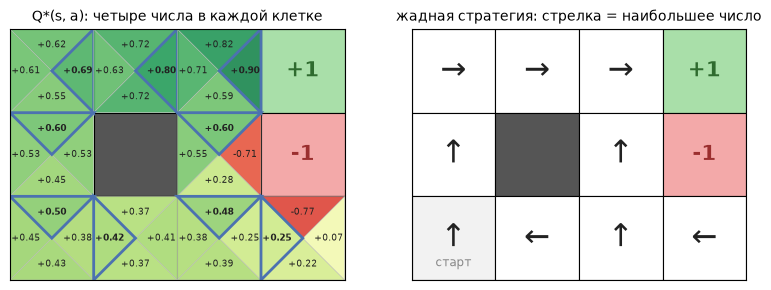

средний return: жадная стратегия +0.51, случайная -0.67


In [4]:
pi_star = greedy_policy(Q_star)                  # в каждой клетке: argmax_a Q*(s, a)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
plot_q(Q_star, env, ax=axes[0], title="Q*(s, a): четыре числа в каждой клетке")
draw_policy(pi_star, env, ax=axes[1], title="жадная стратегия: стрелка = наибольшее число")
plt.show()

rng = np.random.default_rng(0)
print(f"средний return: жадная стратегия {average_return(env, pi_star, rng):+.2f}, "
      f"случайная {average_return(env, uniform_policy(env), rng):+.2f}")

Разница огромная: $+0.5$ против $-0.7$. И обратите внимание на клетку 9 (нижний ряд, вторая): жадная стрелка ведёт **влево**, в сторону от выхода. Агент идёт длинным путём вдоль левого края, лишь бы не проходить под ямой, где ветер может его туда сдуть. Это не эвристика, которую кто-то придумал, — это следствие чисел.

### 3.1 Q или V: в чём разница

Рядом с $Q$ всегда ходит вторая функция — **ценность состояния** $V(s)$: сколько в среднем соберём, **просто оказавшись** в клетке $s$ и дальше играя хорошо. Разница между ними — ровно в том, фиксируем ли мы первое действие.

![V и Q](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/v_vs_q.png)

* $V(s)$ — **одно** число на клетку: «насколько хорошо здесь оказаться».
* $Q(s, a)$ — **четыре** числа на клетку (по одному на действие): «насколько хорошо отсюда сделать вот это».
* Связь: $V(s) = \max_a Q(s, a)$ — ценность клетки равна ценности лучшего действия в ней.

Практическая разница важнее формальной. Из $Q$ стратегия достаётся мгновенно: сравни четыре числа и выбери наибольшее. Из $V$ — **нет**: чтобы понять, какое действие ведёт в хорошую клетку, нужно знать, куда какое действие ведёт, то есть модель среды. Поэтому алгоритмы, которые учатся без модели (Q-learning, DQN), учат именно $Q$, а $V$ используют как вспомогательную величину.

Осталось понять главное: откуда берутся сами числа.

## 4. Уравнение Беллмана

Вот ключевое наблюдение, из которого всё вырастает. Мы сидим в клетке $s$ и выбираем действие $a$. Дальше происходит вот что: мы получаем награду за шаг, среда переносит нас в какую-то клетку $s'$ — и **из $s'$ нас ждёт ровно такая же задача**, только из другой клетки. Прошлое на неё не влияет: правила мира не меняются, а как мы попали в $s'$, неважно.

Значит, ценность действия можно расписать на один шаг вперёд:

> **сколько соберу отсюда = награда за шаг + (с дисконтом) сколько соберу оттуда, куда попаду**,

усреднив по всем исходам ветра. Посчитаем это руками для двух действий из старта.

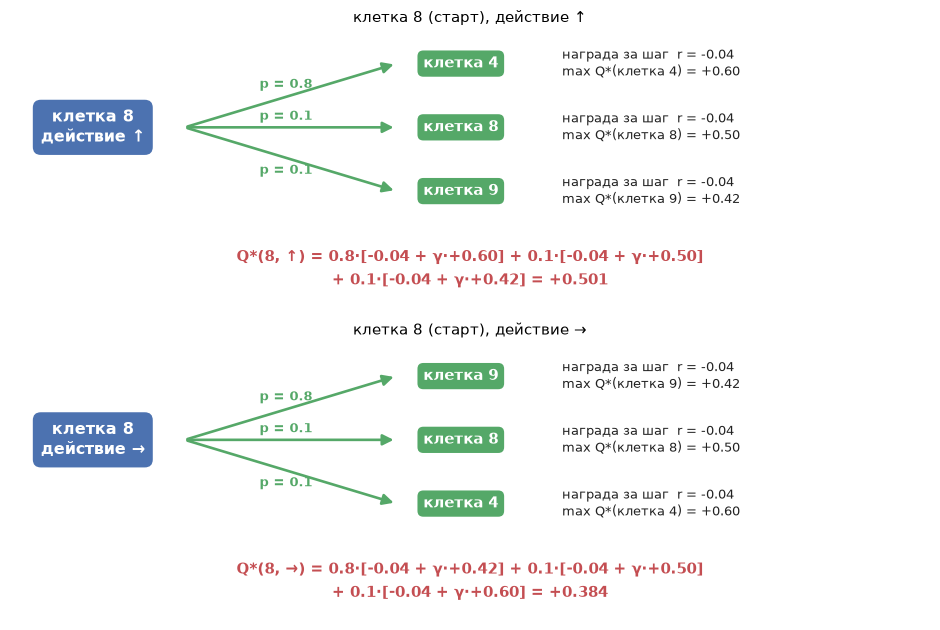

а вот те же числа из таблицы: Q*(8, ↑) = +0.501,  Q*(8, →) = +0.384


In [5]:
def outcomes(s, a):                              # исходы одного действия: (вероятность, куда, награда, ценность той клетки)
    return [(prob, s_next, reward, V_star[s_next]) for prob, s_next, reward, _ in env.transitions(s, a)]

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4))
draw_backup(env, 8, 3, outcomes(8, 3), GAMMA, ax=axes[0], title="клетка 8 (старт), действие ↑")
draw_backup(env, 8, 2, outcomes(8, 2), GAMMA, ax=axes[1], title="клетка 8 (старт), действие →")
plt.tight_layout(); plt.show()

print(f"а вот те же числа из таблицы: Q*(8, ↑) = {Q_star[8, 3]:+.3f},  Q*(8, →) = {Q_star[8, 2]:+.3f}")

Арифметика «на один шаг вперёд» дала ровно те числа, что стоят в таблице $Q^*$. И сразу видно, почему из старта выгоднее вверх, чем вправо: оба действия стоят −0.04, но «вверх» с вероятностью 0.8 приводит в клетку ценности $+0.60$, а «вправо» — в клетку ценности $+0.42$.

Запишем то же самое буквами. Ожидаемое значение по исходам ветра обозначим $\mathbb E$, дисконт — $\gamma$:

$$
\boxed{\;Q^*(s, a) = \mathbb E_{s'}\Big[\, r + \gamma \max_{a'} Q^*(s', a') \,\Big]\;}
$$

Это **уравнение оптимальности Беллмана**. В нём $\max_{a'}$ появился потому, что после перехода мы снова будем выбирать лучшее действие — то есть в правой части стоит $V^*(s') = \max_{a'} Q^*(s', a')$.

Особенность уравнения в том, что неизвестная функция стоит **по обе стороны**. Для нашего мира это система из $12 \times 4 = 48$ уравнений с 48 неизвестными. Система нелинейная (из-за максимума), но у неё есть единственное решение, и его можно найти **методом простой итерации**: взять любое начальное приближение, подставить его в правую часть, получить новое — и так до сходимости.

> Если у нас есть какое-то приближение $Q$, то вычисление правой части уравнения даёт приближение **лучше**. Это единственное, что нужно запомнить из раздела.

Три строки кода — и мы получаем то, что в разделе 3 «выдал добрый человек». Алгоритм называется **value iteration**.

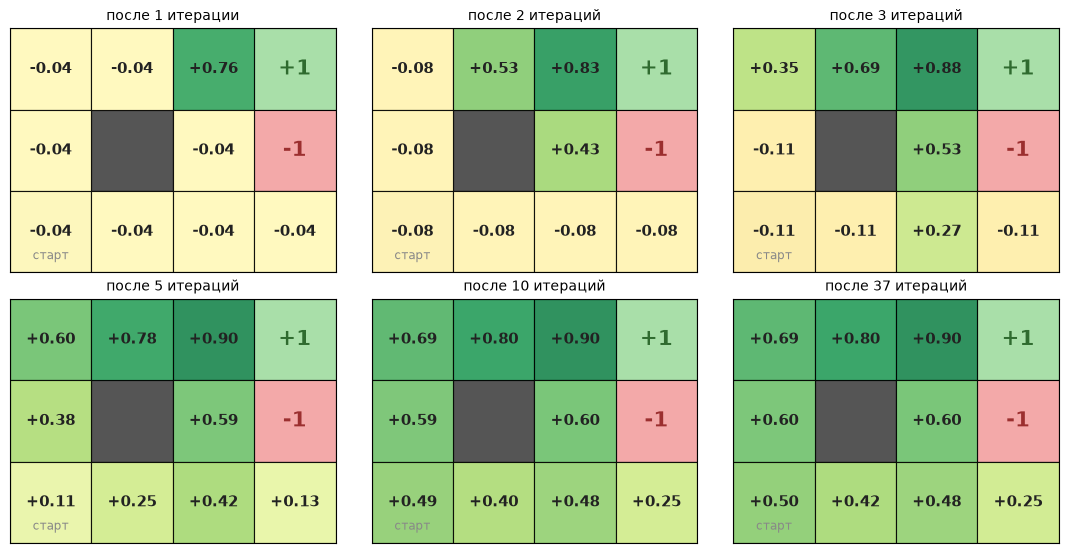

сошлось за 37 итераций; совпадает с таблицей из раздела 3: True


In [6]:
Q, frames = np.zeros((env.n_states, env.n_actions)), {}
for k in range(1, 1000):
    Q_new = R + GAMMA * P @ Q.max(axis=1)        # правая часть уравнения сразу для всех пар (s, a)
    if k in (1, 2, 3, 5, 10):
        frames[k] = Q_new.max(axis=1)
    if np.abs(Q_new - Q).max() < 1e-10:
        Q = Q_new; frames[k] = Q.max(axis=1); break
    Q = Q_new

fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
for ax, (k, values) in zip(axes.ravel(), frames.items()):
    plot_values(values, env, ax=ax, title=f"после {k} итераций" if k > 1 else "после 1 итерации")
plt.tight_layout(); plt.show()
print(f"сошлось за {k} итераций; совпадает с таблицей из раздела 3: {np.allclose(Q, Q_star)}")

Посмотрите, как считаются числа. После первой итерации ненулевые оценки есть только рядом с выходом: остальные клетки «не знают» ни про +1, ни про −1, у них только −0.04 за шаг. Каждая следующая итерация продвигает информацию ещё на одну клетку — знание о награде расходится от выхода волной и через десяток итераций накрывает всё поле.

Полезная деталь: ценность падает по мере удаления от выхода не только из-за платы за шаги, но и потому, что дальний путь — это больше шансов, что ветер снесёт куда-то не туда.

**⏱ Зачем вообще считать, если стрелки можно расставить руками?** Потому что ответ зависит от условий задачи так, что угадать его нельзя. Изменим только одно число — плату за шаг.

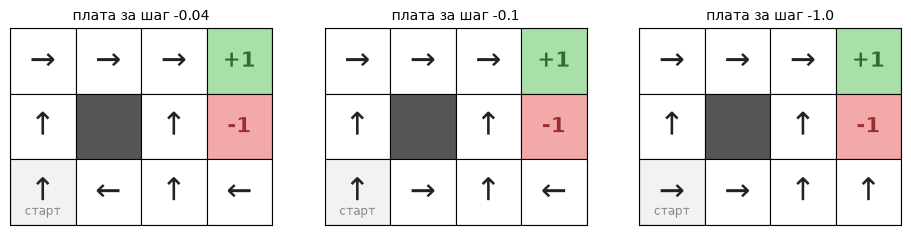

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, step_cost in zip(axes, [-0.04, -0.1, -1.0]):
    e = GridWorld(step_reward=step_cost)
    Pc, Rc = mdp_matrices(e)
    draw_policy(greedy_policy(solve_q_star(Pc, Rc)), e, ax=ax, title=f"плата за шаг {step_cost}")
plt.show()

При плате 0.04 за шаг агент терпелив: из клетки 9 идёт **влево**, длинным безопасным путём в обход ямы. При 0.1 он уже торопится и идёт **вправо**, вплотную под ямой, рискуя, что ветер его туда сдует. При 1.0 за шаг жизнь настолько дорога, что из клетки 11 агент лезет **вверх**, прямо к яме: −1 один раз лучше, чем десяток шагов по −1.

Все три стратегии оптимальны — каждая для своей задачи. Награда задаёт задачу, а уравнение находит ответ; на глаз такие переключения не угадываются.

## 5. Это называется MDP

Мы уже пользовались всеми составными частями задачи — пора назвать их по именам. Задача RL задаётся **марковским процессом принятия решений** (Markov Decision Process, MDP) — четвёркой $(\mathcal S, \mathcal A, p, r)$:

* $\mathcal S$ — множество **состояний** (у нас 12 клеток);
* $\mathcal A$ — множество **действий** (четыре направления);
* $p(s' \mid s, a)$ — **функция переходов**: с какой вероятностью среда перейдёт в $s'$, если в $s$ выбрать $a$ (у нас это ветер 0.8 / 0.1 / 0.1);
* $r$ — **функция награды** (−0.04 за шаг, ±1 в конце).

Агент действует по **стратегии** $\pi(a \mid s)$ — правилу, как выбирать действие; она может быть случайной. Взаимодействие порождает **траекторию** $s_0, a_0, r_0, s_1, a_1, r_1, \ldots$, а её кусок до терминального состояния — **эпизод**.

**Цель**: максимизировать среднюю суммарную награду, где награда через $t$ шагов умножается на $\gamma^t$ ($\gamma = 0.95$ у нас):

$$
J(\pi) = \mathbb E_{\tau \sim \pi} \Big[\, \sum_{t \ge 0} \gamma^t r_t \,\Big] \;\to\; \max_\pi
$$

Сумма под матожиданием — тот самый **return** $G_t$ из лекции 1. Дисконт $\gamma < 1$ нужен по трём причинам: сумма остаётся конечной даже в бесконечной задаче, агент предпочитает награду раньше («тортик сегодня лучше тортика завтра»), и, как мы видели, горизонт планирования становится конечным. У return есть свойство, из которого и вырос раздел 4: return с шага $t$ — это награда сейчас плюс дисконтированный return со следующего шага.

![return](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/return_recursion.png)

В определении MDP спрятаны два предположения. **Марковость**: следующее состояние зависит только от текущего состояния и действия, а не от всей истории. Это требование не к миру, а к тому, что мы называем состоянием: одной фотографии летящего мяча мало, нужна ещё скорость. **Стационарность**: правила не меняются со временем. Если агент видит не всё состояние, а лишь его часть, говорят о частично наблюдаемой задаче (POMDP); на практике в наблюдение добавляют историю — например, DQN в Atari подаёт в сеть четыре последних кадра.

![наблюдение](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/observation_vs_state.png)

Формализм общий: под него подходят и клетчатые миры, где все состояния можно перечислить (такие MDP называют **табличными**), и видеоигры, где состояние — картинка с экрана и таблицу уже не выписать, и управление роботом, где действия непрерывны. Разница только в том, помещается ли таблица в память и можно ли перебрать действия; математика раздела 4 одна и та же.

## 6. Насколько хороша заданная стратегия

До сих пор мы спрашивали «как ходить лучше всего». Но часто нужен ответ на другой вопрос: **насколько хороша вот эта конкретная стратегия** — случайная, написанная руками, выученная вчера? Для неё те же ценности определяются так же, только с пометкой $\pi$: $V^\pi(s)$ — сколько соберём из клетки $s$, если дальше действовать по $\pi$; $Q^\pi(s, a)$ — то же с фиксированным первым действием.

Уравнение для них отличается от раздела 4 **ровно одним символом**.

![два уравнения](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/two_equations.png)

Где в уравнении оптимальности стоял $\max_a$ («дальше агент выберет лучшее»), здесь стоит усреднение по стратегии $\sum_a \pi(a \mid s)$ («дальше агент сделает то, что велит $\pi$»). Практическое следствие: без максимума уравнение становится **линейным**, а линейную систему можно решить точно одной строкой — без всяких итераций и без единого сыгранного эпизода.

Проверим на случайной стратегии: сравним точное решение с оценкой по 3000 эпизодов, как в лекции 1.

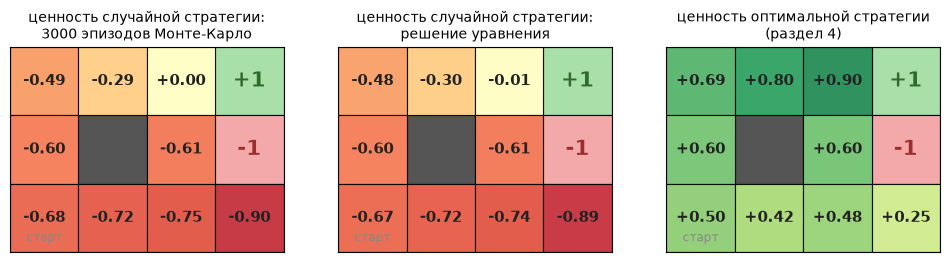

расхождение точного решения и Монте-Карло: 0.009


In [8]:
uniform = uniform_policy(env)
P_pi = np.einsum("sa,sat->st", uniform, P)                         # переходы при фиксированной стратегии
r_pi = (uniform * R).sum(axis=1)                                   # средняя награда за шаг
V_uniform = np.linalg.solve(np.eye(env.n_states) - GAMMA * P_pi, r_pi)   # решение линейной системы

rng = np.random.default_rng(1)
V_mc = estimate_values_mc([run_episode(env, uniform, rng) for _ in range(3000)], env.n_states)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
plot_values(V_mc, env, ax=axes[0], title="ценность случайной стратегии:\n3000 эпизодов Монте-Карло")
plot_values(V_uniform, env, ax=axes[1], title="ценность случайной стратегии:\nрешение уравнения")
plot_values(V_star, env, ax=axes[2], title="ценность оптимальной стратегии\n(раздел 4)")
plt.show()
print(f"расхождение точного решения и Монте-Карло: {np.nanmax(np.abs(V_uniform - V_mc)):.3f}")

Одна строка `np.linalg.solve` дала то же, на что Монте-Карло потратил 3000 эпизодов, и дала точно — правая карта не шумит. А заодно видно, насколько случайная стратегия плоха: из старта она набирает −0.67 против +0.50 у оптимальной, и ценность отрицательна **во всех** клетках, даже в соседней с выходом.

Зачем это нужно на практике: так сравнивают две стратегии между собой, а ещё — улучшают стратегию по шагам. Если посчитать $Q^\pi$ и в каждой клетке пересесть на жадное действие, новая стратегия гарантированно не хуже старой; повторяя, приходим к оптимальной. Этот алгоритм называется policy iteration, он ждёт нас на неделе 3.

## 7. Когда модель неизвестна: Q-learning

У всего предыдущего есть одно слабое место: чтобы посчитать правую часть уравнения, нужно знать $p(s' \mid s, a)$ и $r$ — устройство среды. У нас они были (мы сами написали мир из 40 строк), а в жизни их нет. Катаясь на велосипеде, вы не можете сказать, с какой вероятностью в каком положении окажетесь через секунду.

Что доступно вместо модели? **Пробовать.** Сделали шаг — узнали четвёрку $(s, a, r, s')$: где были, что сделали, что получили, куда попали. Она называется **переходом**, и это наша единица опыта. Заметьте: $s'$ — это честный образец из $p(s' \mid s, a)$, просто выданный самой средой.

Тогда матожидание в уравнении можно заменить одним наблюдением:

$$
y = r + \gamma \max_{a'} Q(s', a') \qquad \text{— \textbf{Беллмановский таргет}}.
$$

Но жёстко заменять оценку на таргет нельзя: нам могло повезти или не повезти с исходом ветра. Поступим как со средним по выборке — будем **сдвигать** оценку в сторону таргета на небольшую долю $\alpha$:

$$
\boxed{\;Q(s, a) \;\leftarrow\; Q(s, a) + \alpha\,\big[\, \underbrace{r + \gamma \max_{a'} Q(s', a')}_{\text{таргет}} - \underbrace{Q(s, a)}_{\text{текущая оценка}} \,\big]\;}
$$

Это **Q-learning**. В среднем такие сдвиги ведут туда же, куда простая итерация раздела 4, — только модель не нужна вовсе.

### 7.1 Колобок и лотерея

Пример из учебника ШАД, на котором формула становится очевидной. Колобок Колабулька стоит у киоска и думает, покупать ли лотерейный билет. Он считает, что после покупки сможет набрать $Q = +100$. Билет стоит 10, а после проигрыша Колобок снова у киоска.

![лотерея](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/lottery_mdp.png)

Таргет: $-10 + \max(100, 0) = 90$. При $\alpha = 0.5$ оценка $+100$ опускается до $95$, потом до $90$, и так далее — пока не везёт, оценка падает. А когда билет наконец выигрывает, таргет становится $-10 + 1000$, и оценка резко подскакивает. Куда всё сойдётся, говорит уравнение оптимальности: если выигрыш случается с вероятностью $1 - p$, то

$$
Q^*(s, \text{купить}) = -10 + p \cdot \max\big(Q^*(s, \text{купить}), 0\big) + (1 - p) \cdot 1000,
$$

и при $p = 0.99$ решение равно нулю: билет за 10 с выигрышем 1000 раз в сто — честная игра, покупать и не покупать одинаково. Проверим обе картины численно.

пять проигрышей подряд, потом выигрыш (α = 0.5): [100.   95.   90.   85.   80.   75.  532.5]


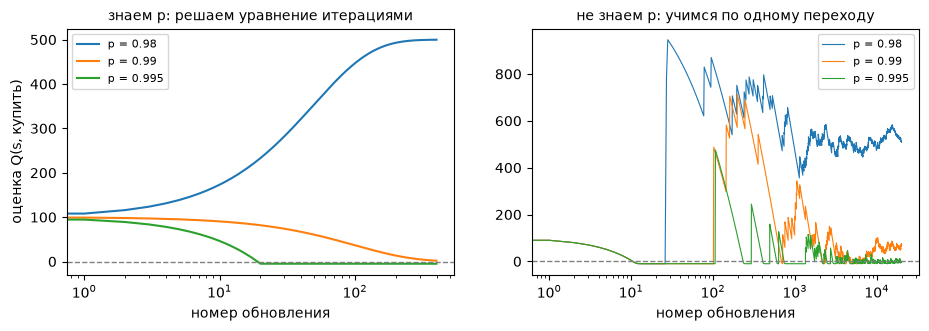

In [9]:
def lottery(outcomes, alpha, q0=100.0):
    """Обновления Q(s, купить) по переходам: outcomes — список True (выигрыш) / False (снова у киоска)."""
    q, history = q0, [q0]
    for k, win in enumerate(outcomes):
        target = -10 + (1000 if win else max(q, 0))        # Беллмановский таргет по одному переходу
        a = alpha(k) if callable(alpha) else alpha
        q += a * (target - q); history.append(q)
    return np.array(history)

print("пять проигрышей подряд, потом выигрыш (α = 0.5):", np.round(lottery([False] * 5 + [True], alpha=0.5), 1))

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for p in [0.98, 0.99, 0.995]:
    exact = [100.0]
    for _ in range(400):
        exact.append(-10 + p * max(exact[-1], 0) + (1 - p) * 1000)         # знаем p: простая итерация
    axes[0].plot(exact, label=f"p = {p}")
    axes[1].plot(lottery(rng.random(20_000) > p, alpha=lambda k: 1 / (1 + k / 100)), lw=0.8, label=f"p = {p}")
axes[0].set_title("знаем p: решаем уравнение итерациями", fontsize=10)
axes[1].set_title("не знаем p: учимся по одному переходу", fontsize=10)
for ax in axes:
    ax.axhline(0, color="grey", ls="--", lw=1); ax.set_xscale("log"); ax.set_xlabel("номер обновления"); ax.legend(fontsize=8)
axes[0].set_ylabel("оценка Q(s, купить)")
plt.show()

Слева — уравнение, решённое с известным $p$; справа — тот же ответ, полученный **только из сыгранных переходов**, без знания вероятностей: шумно, медленнее, но туда же.

### 7.2 Как собирать данные

Остался вопрос: какие действия выбирать, пока учимся? Если всегда брать жадное по текущей оценке, многие пары «клетка — действие» никогда не попробуем и не узнаем, что там. Классический пример: агент один раз врезался на велосипеде, получил −5 и решил вообще не садиться, потому что «ничего не делать» даёт 0. Поэтому исследование обязательно: с вероятностью $\varepsilon$ берём случайное действие, иначе жадное. Это **$\varepsilon$-жадная стратегия**. В начале обучения $\varepsilon$ держат большим, потом уменьшают.

Соберём алгоритм целиком — он помещается в восемь строк.

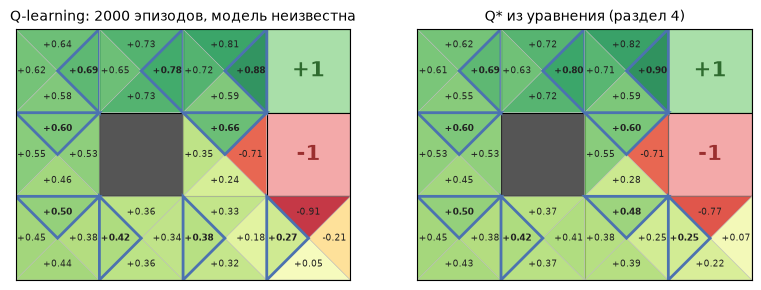

оценка старта: выучено +0.50, точное значение +0.50; средний return жадной стратегии по выученной таблице: +0.50


In [10]:
Q_learned = np.zeros((env.n_states, env.n_actions))
rng, alpha, n_episodes = np.random.default_rng(0), 0.1, 2000
for episode in range(n_episodes):
    eps = max(0.1, 1 - episode / (n_episodes / 2))               # сначала исследуем, потом пользуемся знаниями
    s, _ = env.reset(seed=int(rng.integers(1_000_000)))
    for _ in range(100):
        a = int(rng.integers(env.n_actions)) if rng.random() < eps else int(Q_learned[s].argmax())
        s_next, r, terminated, truncated, _ = env.step(a)        # единственный источник знаний о мире
        Q_learned[s, a] += alpha * (r + GAMMA * Q_learned[s_next].max() - Q_learned[s, a])
        s = s_next
        if terminated or truncated:
            break

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
plot_q(Q_learned, env, ax=axes[0], title=f"Q-learning: {n_episodes} эпизодов, модель неизвестна")
plot_q(Q_star, env, ax=axes[1], title="Q* из уравнения (раздел 4)")
plt.show()
print(f"оценка старта: выучено {Q_learned[8].max():+.2f}, точное значение {V_star[8]:+.2f}; "
      f"средний return жадной стратегии по выученной таблице: {average_return(env, greedy_policy(Q_learned), np.random.default_rng(3), 500):+.2f}")

Таблица, собранная из двух тысяч сыгранных эпизодов, почти совпала с решением уравнения, а стратегия по ней приносит столько же, сколько оптимальная. Агент ни разу не заглянул в устройство мира: он пробовал, ошибался и после каждого шага чуть-чуть двигал одно число.

Это и есть ответ на вопрос из начала лекции. Cross-Entropy оценивал эпизод целиком; Q-learning оценивает **каждый шаг** — и потому обходится несравнимо меньшим числом эпизодов.

## 8. Итоги

1. **Ценность — это оценка шага.** $Q(s, a)$ — сколько соберём, сделав действие $a$ в клетке $s$ и дальше играя хорошо; $V(s) = \max_a Q(s, a)$ — то же без выбора действия. Из $Q$ стратегия получается сразу: выбирай наибольшее (принцип оптимальности Беллмана).
2. **Уравнение Беллмана связывает оценки соседей:** ценность = награда за шаг + дисконтированная ценность того, куда попадём, усреднённая по исходам. Неизвестное стоит по обе стороны, и решается это методом простой итерации — алгоритм value iteration.
3. **Два вопроса — два уравнения.** Для лучшей стратегии в правой части $\max_a$; для заданной стратегии — усреднение по $\pi$, и тогда система линейна и решается точно.
4. **Всё это — про MDP** $(\mathcal S, \mathcal A, p, r)$ с марковским свойством и дисконтом $\gamma$; цель — максимум средней дисконтированной награды.
5. **Если модель неизвестна**, матожидание заменяют одним переходом $(s, a, r, s')$ и сдвигают оценку к Беллмановскому таргету с шагом $\alpha$ — это Q-learning, первый алгоритм курса, который учится с каждого шага.

![карта](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/bellman_family.png)

Дальше в курсе меняется только то, что именно мы не можем себе позволить: таблицу $Q$ (тогда её заменяет нейросеть — DQN, неделя 6), знание модели (Monte-Carlo и TD, неделя 3) или перебор действий (actor-critic, недели 8–9). Уравнение остаётся тем же.

Словарь лекции: **ценность действия $Q$, ценность состояния $V$, жадная стратегия, принцип оптимальности Беллмана, уравнение Беллмана, метод простой итерации, value iteration, MDP, функция переходов, стратегия, траектория, эпизод, дисконт, return, переход $(s, a, r, s')$, Беллмановский таргет, Q-learning, $\varepsilon$-жадная стратегия**.

## Литература

* [Учебник по машинному обучению ШАД, глава «Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) — первоисточник сегодняшнего изложения, дальше там DQN и policy gradient.
* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction* — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). Глава 3 — MDP и уравнения Беллмана, глава 4 — динамическое программирование, раздел 6.5 — Q-learning.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), лекции 2 и 3.
* [Демонстрация value iteration в браузере](https://cs.stanford.edu/people/karpathy/reinforcejs/gridworld_dp.html) — тот же клетчатый мир, можно покрутить $\gamma$ и посмотреть, как меняются числа.

## На семинаре и дома

* **Семинар** (`../seminar/seminar.ipynb`): пишем свой клетчатый мир как среду Gymnasium, достаём из неё $p$ и $r$, считаем ценность стратегии тремя способами, делаем шаг жадного улучшения, решаем уравнение оптимальности и запускаем Q-learning.
* **ДЗ** (`../homework/homework.ipynb`): среда «управление запасами», её модель из распределения спроса, оптимальная стратегия заказов из уравнения; теория — вывод уравнений Беллмана и лотерея Колобка.
* **Неделя 3**: policy iteration, Monte-Carlo и TD-обучение, SARSA и Q-learning подробно — и почему всё это сходится.